# Weekly Project 03 - Multiple View Geometry 1

## Implementation of stereo block matching

This week you'll be implementing your own block matching algorithm for stereo depth reconstruction. Thus you are not allowed to use cv2.matchTemplate, cv2.stereoBM or similar functions from opencv or other pre-existing libraries. You can find all necessary image-files in the attached zip-file.

It is recommended you use the following three intermediate steps before going directly to a full implementation:

### Intermediate step 1:

Implement a function that takes two equal size images and calculates the sum of absolute differences. The two equal-sized images are nose_left.png (used as the template) and nose_right.png.

### Intermediate step 2:

Using the function you just created, find which of the three images nose1.png, nose2.png, nose3.png gives the best match to nose_left.png?

### Intermediate step 3:

Since these images are rectified, we can approximately assume that a pixel found in row x in the left image also lives in row x in the right image. nose_span.png contains the entire row containing the nose of the sculpture. The height of the span is 7 - the same height as your template. Write a function that loops through the image from left to right and computes the correlation using your function from step 1 to find where in the span the nose is located.

### Full template matching implementation (Challenge):

Write a template matching function that iteratively takes a 7x7 subpart (numpy calls this slicing) of tsukuba_left.png and uses your function from step 3 to apply it to the corresponding row in tsukuba_right.png and stores the lowest/best matching disparity value for that template. Continue until all possible templates for a row has been used before moving down to the next row in the image.

## Weekly Project 03 - Start Here

### Intermediate step 1:


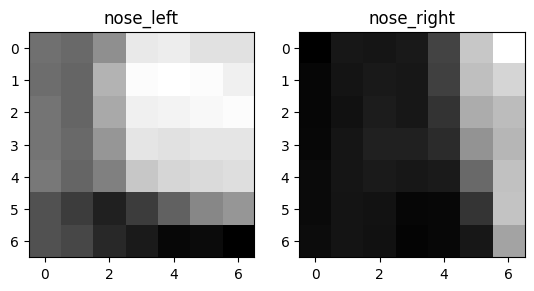

In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

template = cv2.imread('nose_left.png')
template = template[...,0]
nose_right = cv2.imread('nose_right.png')
nose_right = nose_right[...,0]
fig, (fig1, fig2) = plt.subplots(1, 2)

# Define os títulos usando set_title (subtitle não existe em subplots)
fig1.set_title('nose_left')
fig2.set_title('nose_right')

fig1.imshow(template, cmap='gray')
fig2.imshow(nose_right, cmap='gray')

#plt.tight_layout()
plt.show()


In [2]:
def calculate_sad(template: np.ndarray, nose_right: np.ndarray) -> int:
    # Converter para int32 para evitar underflow do tipo uint8
    template_signed = template.astype(np.int32)
    nose_right_signed = nose_right.astype(np.int32)

    # Diferença absoluta pixel a pixel e soma de todos os elementos
    return np.sum(np.abs(template_signed - nose_right_signed))

### Intermediate step 2:


In [3]:
noses = [
    cv2.imread('nose1.png')[...,0],
    cv2.imread('nose2.png')[...,0],
    cv2.imread('nose3.png')[...,0],
]
sad_noses = []
for i in range(3):
    score = calculate_sad(template, noses[i])
    sad_noses.append(score)
    print(f'SAD value for nose {i+1}: {sad_noses[i]}')
print(f'Min value: {np.min(sad_noses)}')

SAD value for nose 1: 1361
SAD value for nose 2: 119
SAD value for nose 3: 1490
Min value: 119


### Intermediate step 3:


SAD value for nose 1: 8708
SAD value for nose 2: 8670
SAD value for nose 3: 8616
SAD value for nose 4: 8560
SAD value for nose 5: 8546
SAD value for nose 6: 8535
SAD value for nose 7: 8522
SAD value for nose 8: 8582
SAD value for nose 9: 8689
SAD value for nose 10: 8798
SAD value for nose 11: 8881
SAD value for nose 12: 8947
SAD value for nose 13: 8987
SAD value for nose 14: 9002
SAD value for nose 15: 8932
SAD value for nose 16: 8837
SAD value for nose 17: 8700
SAD value for nose 18: 8572
SAD value for nose 19: 8428
SAD value for nose 20: 8318
SAD value for nose 21: 8215
SAD value for nose 22: 8165
SAD value for nose 23: 8111
SAD value for nose 24: 8095
SAD value for nose 25: 8066
SAD value for nose 26: 8066
SAD value for nose 27: 8050
SAD value for nose 28: 8056
SAD value for nose 29: 8035
SAD value for nose 30: 8037
SAD value for nose 31: 8017
SAD value for nose 32: 8020
SAD value for nose 33: 8006
SAD value for nose 34: 8003
SAD value for nose 35: 7981
SAD value for nose 36: 7983
S

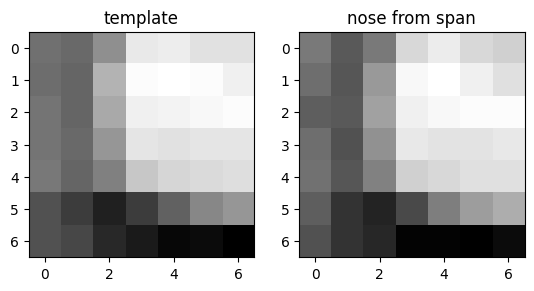

In [13]:
nose_span = cv2.imread('nose_span.png')[...,0]
sad_nose_span =[]

nose_span_rows, nose_span_columns = nose_span.shape
template_rows, template_columns = template.shape

for i in range(nose_span_columns - template_columns + 1):
    score = calculate_sad(nose_span[:,i:i+template_columns], template)
    sad_nose_span.append(score)
    print(f'SAD value for nose {i+1}: {sad_nose_span[i]}')
print(f'Min value: {np.min(sad_nose_span)}')
best_index = np.argmin(sad_nose_span)
print(f'Min value index: {best_index}')




fig, (fig1, fig2) = plt.subplots(1, 2)

# Define os títulos usando set_title (subtitle não existe em subplots)
fig1.set_title('template')
fig2.set_title('nose from span')

fig1.imshow(template, cmap='gray')
fig2.imshow(nose_span[:, best_index:best_index + template_columns], cmap = 'gray')

#plt.tight_layout()
plt.show()


### Full template matching implementation (Challenge):

In [15]:
import cv2
import numpy as np

template = cv2.imread('tsukuba_left.png', cv2.IMREAD_GRAYSCALE)
tsukuba_right = cv2.imread('tsukuba_right.png', cv2.IMREAD_GRAYSCALE)

rows, columns = template.shape
block_size = 7

disparity_map = np.zeros((rows, columns), dtype=np.uint8)

# Percorre as linhas e colunas da imagem esquerda (c)
for r in range(rows - block_size + 1):
    for c in range(columns - block_size + 1):
        # 1. Bloco 7x7 do template
        block_7x7 = template[r : r + block_size, c : c + block_size]

        # 2. Faixa horizontal na imagem direita
        right_row_strip = tsukuba_right[r : r + block_size, :]

        # 3. Lista local para guardar os SADs deste bloco específico
        sad_scores = []

        # 4. Percorre a faixa da imagem direita (c_right) com o limite correto
        for c_right in range(columns - block_size + 1):
            right_block = right_row_strip[:, c_right : c_right + block_size]

            # Usa o block_7x7 (e nao a imagem inteira 'template')
            score = calculate_sad(right_block, block_7x7)
            sad_scores.append(score)

        # 5. Encontra a coluna da direita com o menor SAD
        best_c_right = np.argmin(sad_scores)

        # 6. Disparidade = diferenca de posicao X (c - c_right)
        disparity = abs(c - best_c_right)

        # 7. Guarda o valor na matriz final
        disparity_map[r, c] = disparity

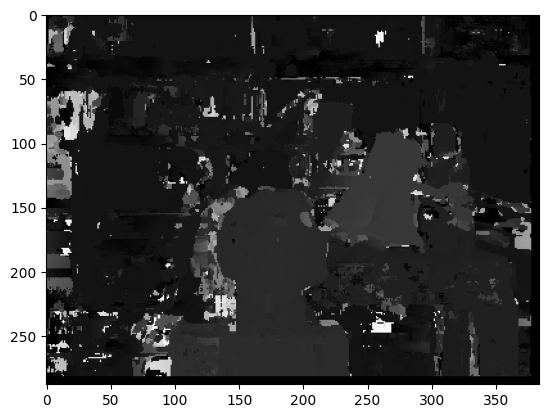

In [17]:
plt.imshow(disparity_map, cmap = 'gray')